In [1]:
# ============================================================
# FULL COLAB SCRIPT
# Morris sampling -> load curtailment outputs (Run1..RunN) ->
# compute Morris factor importance/ranking on total curtailment
# (automatically uses ONLY completed trajectories)
# ============================================================

import numpy as np
import pandas as pd
import re
import requests
from io import StringIO
from pathlib import Path

# =========================
# USER INPUTS
# =========================
URL_BOUNDS = "https://raw.githubusercontent.com/Raziye-Aghapour/ReEDS_Morris/refs/heads/main/all_multiplier_bounds.csv"

# Morris design settings
R_TRAJ = 5          # number of Morris trajectories you *intend* to run
P_LEVELS = 6        # grid levels (recommended >= 6)
SEED = 123

# GitHub folder holding outputs curt_ann_Sc_RunX.csv
OWNER = "Raziye-Aghapour"
REPO  = "ReEDS_Morris"
FOLDER_PATH = "Curtailment annual"
FILENAME_REGEX = r"^curt_ann_Sc_Run(\d+)\.csv$"

# Output directory for files
OUTDIR = Path("morris_samples")
OUTDIR.mkdir(exist_ok=True)

# ============================================================
# 1) READ BOUNDS TABLE
# ============================================================
bounds_df = pd.read_csv(URL_BOUNDS)

bounds_df["Parameter"] = bounds_df["Parameter"].astype(str).str.strip()
bounds_df["Unit"] = bounds_df["Unit"].astype(str).str.strip()
bounds_df["Upperbound"] = pd.to_numeric(bounds_df["Upperbound"], errors="coerce")
bounds_df["Lowerbound"] = pd.to_numeric(bounds_df["Lowerbound"], errors="coerce")
bounds_df = bounds_df.dropna(subset=["Parameter", "Upperbound", "Lowerbound"]).reset_index(drop=True)

# ============================================================
# 2) MAKE SAFE FACTOR NAMES
# ============================================================
def slugify(name: str) -> str:
    s = name.strip().lower()
    s = s.replace("&", "and")
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s

bounds_df["factor"] = bounds_df["Parameter"].apply(slugify)

# Ensure uniqueness in case two parameters slugify to the same string
if bounds_df["factor"].duplicated().any():
    counts = {}
    new = []
    for f in bounds_df["factor"]:
        counts[f] = counts.get(f, 0) + 1
        new.append(f"{f}__{counts[f]}")
    bounds_df["factor"] = new

# ============================================================
# 3) MORRIS TRAJECTORIES (SCALED TO BOUNDS)
# ============================================================
def morris_trajectories(bounds: pd.DataFrame, r: int, p: int, seed: int = 123):
    """
    Returns:
      design_wide: DataFrame with run_id, factor columns (scaled), trajectory, step, changed_factor
      factor_map:  DataFrame mapping factor -> original parameter + bounds + unit
      delta:       normalized delta in [0,1] (for reference)
    """
    rng = np.random.default_rng(seed)
    k = len(bounds)

    grid = np.linspace(0, 1, p)
    delta = p / (2 * (p - 1))

    start_candidates = grid[grid <= (1 - delta + 1e-12)]
    if len(start_candidates) == 0:
        raise ValueError(
            f"No valid starting points for p={p} (delta={delta:.4f}). Increase p (e.g., 6, 8, 10)."
        )

    X_all = []
    meta_rows = []
    run_id = 0

    for traj in range(r):
        x = rng.choice(start_candidates, size=k, replace=True)
        order = rng.permutation(k)
        directions = rng.choice([-1, 1], size=k)

        # First point
        X_all.append(x.copy())
        meta_rows.append({"run_id": run_id, "trajectory": traj, "step": 0, "changed_factor": ""})
        run_id += 1

        for step, j in enumerate(order, start=1):
            x_new = x.copy()
            d = directions[j] * delta
            if not (0 <= x_new[j] + d <= 1):
                d = -d
            x_new[j] = x_new[j] + d
            x_new[j] = grid[np.argmin(np.abs(grid - x_new[j]))]

            X_all.append(x_new.copy())
            meta_rows.append({
                "run_id": run_id,
                "trajectory": traj,
                "step": step,
                "changed_factor": bounds.loc[j, "factor"],
            })
            run_id += 1
            x = x_new

    X = np.vstack(X_all)

    lo = bounds["Lowerbound"].to_numpy(dtype=float)
    hi = bounds["Upperbound"].to_numpy(dtype=float)
    X_scaled = lo + X * (hi - lo)

    meta = pd.DataFrame(meta_rows)
    design = pd.DataFrame(X_scaled, columns=bounds["factor"].tolist())
    design.insert(0, "run_id", meta["run_id"].values)
    design = pd.concat([design, meta[["trajectory", "step", "changed_factor"]]], axis=1)

    factor_map = bounds[["factor", "Parameter", "Lowerbound", "Upperbound", "Unit"]].copy()
    return design, factor_map, delta

design, factor_map, delta = morris_trajectories(bounds_df, r=R_TRAJ, p=P_LEVELS, seed=SEED)

design_path = OUTDIR / f"morris_design_r{R_TRAJ}_p{P_LEVELS}.csv"
map_path = OUTDIR / "morris_factor_map.csv"
design.to_csv(design_path, index=False)
factor_map.to_csv(map_path, index=False)

k = len(bounds_df)
n_runs = len(design)

print("=== Morris sampling created ===")
print(f"Factors (k): {k}")
print(f"Trajectories (r): {R_TRAJ}")
print(f"Grid levels (p): {P_LEVELS}")
print(f"Delta (normalized): {delta:.6f}")
print(f"Total runs: r*(k+1) = {R_TRAJ}*({k}+1) = {n_runs}")
print(f"Wrote: {design_path}")
print(f"Wrote: {map_path}")

# ============================================================
# 4) LOAD CURTAILMENT OUTPUTS FROM GITHUB (Run1..RunN)
#    Store each run as its own DataFrame in run_dfs
# ============================================================
def github_list_folder(owner: str, repo: str, folder_path: str):
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{folder_path}"
    r = requests.get(api_url, headers={"Accept": "application/vnd.github+json"})
    r.raise_for_status()
    return r.json()

def discover_runs(owner: str, repo: str, folder_path: str, filename_regex: str):
    items = github_list_folder(owner, repo, folder_path)
    out = []
    for it in items:
        name = it.get("name", "")
        m = re.match(filename_regex, name)
        if m:
            run_id = int(m.group(1))
            out.append((run_id, it["download_url"]))
    out.sort(key=lambda x: x[0])
    return out

def parse_curtailment_csv(text: str) -> pd.DataFrame:
    """
    Preferred: standard CSV with newlines:
      r,t,Value
      p60,2015,0.0
      ...

    Fallback: flattened stream or mixed separators.
    """
    text = text.replace("\ufeff", "").strip()

    # Try normal CSV first
    try:
        df = pd.read_csv(StringIO(text))
        df.columns = [c.strip().replace("\n", "") for c in df.columns]
        if set(["r", "t", "Value"]).issubset(df.columns) and len(df) > 0:
            return df[["r", "t", "Value"]]
    except Exception:
        pass

    # Fallback tokenize
    tokens = [tok for tok in re.split(r"[,\s]+", text) if tok != ""]
    if len(tokens) < 6:
        raise ValueError("File content too short to parse.")

    header = tokens[:3]
    data = tokens[3:]
    leftover = len(data) % 3
    if leftover != 0:
        data = data[:len(data) - leftover]

    rows = [data[i:i+3] for i in range(0, len(data), 3)]
    df = pd.DataFrame(rows, columns=header)
    df.columns = [c.strip().replace("\n", "") for c in df.columns]
    return df[["r", "t", "Value"]]

def clean_types(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["t"] = pd.to_numeric(df["t"], errors="coerce").astype("Int64")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df.dropna(subset=["r", "t", "Value"])
    return df

def load_one_run(run_id: int, url: str) -> pd.DataFrame:
    r = requests.get(url)
    r.raise_for_status()
    df = parse_curtailment_csv(r.text)
    return clean_types(df)

runs_found = discover_runs(OWNER, REPO, FOLDER_PATH, FILENAME_REGEX)
print(f"\nDiscovered {len(runs_found)} run file(s): {[rid for rid, _ in runs_found]}")

run_dfs = {}
failed = {}
for rid, url in runs_found:
    try:
        run_dfs[rid] = load_one_run(rid, url)
    except Exception as e:
        failed[rid] = str(e)

print(f"Loaded runs: {sorted(run_dfs.keys())}")
if failed:
    print("Failed runs:", failed)

# ============================================================
# 5) MORRIS IMPORTANCE/RANKING ON TOTAL CURTAILMENT
#    Automatically uses ONLY completed trajectories
# ============================================================
def total_curtailment_per_run(run_dfs: dict) -> pd.DataFrame:
    rows = []
    for run, df in run_dfs.items():
        y = float(pd.to_numeric(df["Value"], errors="coerce").fillna(0.0).sum())
        rows.append({"run": int(run), "y": y})
    return pd.DataFrame(rows).sort_values("run").reset_index(drop=True)

outcome_df = total_curtailment_per_run(run_dfs)

# Attach outcomes (design.run_id is 0-based; files are Run1-based)
design_y = design.copy()
outcome_df2 = outcome_df.copy()
outcome_df2["run_id"] = outcome_df2["run"] - 1
design_y = design_y.merge(outcome_df2[["run_id", "y"]], on="run_id", how="left")

print(f"\nOutcome coverage on design rows: {design_y['y'].notna().mean():.1%} "
      f"({design_y['y'].notna().sum()} / {len(design_y)})")

# Factor columns from design (prevents KeyError)
META = {"run_id", "trajectory", "step", "changed_factor", "y"}
factors = [c for c in design_y.columns if c not in META]
k = len(factors)
needed = k + 1
print(f"Detected k={k} factors -> need {needed} runs per trajectory.")

# Identify completed trajectories
traj_stats = (
    design_y.assign(has_y=design_y["y"].notna())
            .groupby("trajectory", as_index=False)
            .agg(n_points=("run_id", "size"),
                 n_with_y=("has_y", "sum"))
)

complete_trajs = traj_stats.loc[
    (traj_stats["n_points"] == needed) & (traj_stats["n_with_y"] == needed),
    "trajectory"
].tolist()

print("Complete trajectories available:", complete_trajs)

if not complete_trajs:
    have = int(design_y["y"].notna().sum())
    raise ValueError(
        f"No complete trajectories yet.\n"
        f"You currently have outcomes for {have} design points, but need {needed} "
        f"for at least one full trajectory."
    )

design_use = design_y[design_y["trajectory"].isin(complete_trajs)].copy()
design_use = design_use.sort_values(["trajectory", "step"]).reset_index(drop=True)

def morris_EE(design_df: pd.DataFrame, factors: list, ycol="y") -> pd.DataFrame:
    df = design_df.sort_values(["trajectory", "step"]).reset_index(drop=True)
    curr = df[df["step"] > 0].copy()

    prev = df[["trajectory", "step", ycol] + factors].copy()
    prev["step"] = prev["step"] + 1
    prev = prev.rename(columns={ycol: ycol + "_prev", **{f: f + "_prev" for f in factors}})

    m = curr.merge(prev, on=["trajectory", "step"], how="left")
    m = m.dropna(subset=[ycol, ycol + "_prev"])
    m = m[m["changed_factor"].astype(str).str.len() > 0].copy()

    out = []
    for f in factors:
        s = m[m["changed_factor"] == f].copy()
        if len(s) == 0:
            continue
        dx = (s[f] - s[f + "_prev"]).astype(float)
        dy = (s[ycol] - s[ycol + "_prev"]).astype(float)
        ok = dx.abs() > 0
        s = s.loc[ok].copy()
        ee = (dy.loc[ok] / dx.loc[ok]).to_numpy()

        out.append(pd.DataFrame({
            "factor": f,
            "trajectory": s["trajectory"].to_numpy(),
            "step": s["step"].to_numpy(),
            "EE": ee
        }))
    if not out:
        raise ValueError("No elementary effects computed. Check changed_factor and outcome alignment.")
    return pd.concat(out, ignore_index=True)

ee_df = morris_EE(design_use, factors, ycol="y")

g = ee_df.groupby("factor")["EE"]
morris_rank = pd.DataFrame({
    "mu": g.mean(),
    "mu_star": g.apply(lambda s: np.mean(np.abs(s))),
    "sigma": g.std(ddof=1),
    "n_EE": g.size()
}).reset_index().sort_values("mu_star", ascending=False).reset_index(drop=True)

morris_rank.insert(0, "rank_mu_star", np.arange(1, len(morris_rank) + 1))

print("\n=== Morris ranking (based on available completed trajectories) ===")
print(morris_rank.head(20))

# Merge readable names (if factor_map matches)
morris_rank_named = morris_rank.merge(factor_map, on="factor", how="left")

# Save outputs
ee_path = OUTDIR / "morris_EE_total_curtailment.csv"
rank_path = OUTDIR / "morris_ranking_total_curtailment.csv"
rank_named_path = OUTDIR / "morris_ranking_total_curtailment_named.csv"

ee_df.to_csv(ee_path, index=False)
morris_rank.to_csv(rank_path, index=False)
morris_rank_named.to_csv(rank_named_path, index=False)

print("\nSaved:")
print(" -", ee_path)
print(" -", rank_path)
print(" -", rank_named_path)

# Optional preview tables (in Colab these will display nicely)
display(morris_rank_named.head(30))


=== Morris sampling created ===
Factors (k): 39
Trajectories (r): 5
Grid levels (p): 6
Delta (normalized): 0.600000
Total runs: r*(k+1) = 5*(39+1) = 200
Wrote: morris_samples/morris_design_r5_p6.csv
Wrote: morris_samples/morris_factor_map.csv

Discovered 200 run file(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 

,rank_mu_star,factor,mu,mu_star,sigma,n_EE,Parameter,Lowerbound,Upperbound,Unit
0,1,gas_ccs_capcost,2.049759e+09,2.049759e+09,4.583400e+09,5,Gas-ccs -- capcost,0.8747,1.1253,$/kW (multiplier)
1,2,offshore_wind_fixed_overnight_cap_cost,-9.556643e+08,9.556643e+08,2.136930e+09,5,Offshore wind -- fixed -- Overnight Cap Cost,0.7848,1.3223,$/kW (multiplier)
2,3,gas_cc_capcost,-2.138813e+08,8.859723e+08,1.475353e+09,5,Gas-CC -- capcost,0.9724,1.0277,$/MW (multiplier)
3,4,electricity_demand_multiplier_tx,6.317592e+08,6.688812e+08,8.917850e+08,5,Electricity demand multiplier -- TX,0.9579,1.0423,unitless (multiplier)
4,5,onshore_wind_cf_mult,-5.900260e+07,4.834925e+08,6.904118e+08,5,Onshore wind -- CF_mult,0.9531,1.0634,unitless (multiplier)
5,6,upv_cf_improvement,-7.134989e+07,4.291109e+08,6.266439e+08,5,UPV -- cf_improvement,0.9390,1.0458,unitless (multiplier)
6,7,gas_cc_heatrate,3.361615e+08,3.960000e+08,5.818357e+08,5,Gas-CC -- heatrate,0.9731,1.0270,MMBtu/MWh (multiplier)
7,8,gas_cc_fom,1.903194e+07,3.885828e+08,5.816689e+08,5,Gas-CC -- fom,0.9500,1.0522,$/MW-yr (multiplier)
8,9,onshore_wind_fixed_oandm_kw_yr,2.809977e+07,2.899387e+08,4.391358e+08,5,Onshore wind -- Fixed O&M $/(kW-yr),0.8218,1.0752,$/kW-yr (multiplier)
9,10,gas_cc_vom,6.279310e+07,2.883482e+08,4.353945e+08,5,Gas-CC -- vom,0.9677,1.0327,$/MWh (multiplier)


In [2]:
# =========================
# Standardized (normalized) EE in [0,1] space
# =========================
# Create normalized copy of factor columns for comparability
lo = factor_map.set_index("factor")["Lowerbound"].to_dict()
hi = factor_map.set_index("factor")["Upperbound"].to_dict()

design_use_norm = design_use.copy()
for f in factors:
    # avoid divide-by-zero if bounds identical (shouldn't happen, but safe)
    rng = (hi[f] - lo[f])
    if rng == 0:
        design_use_norm[f] = np.nan
    else:
        design_use_norm[f] = (design_use_norm[f] - lo[f]) / rng

ee_df_norm = morris_EE(design_use_norm, factors, ycol="y")

# Rank using standardized EEs
g = ee_df_norm.groupby("factor")["EE"]
morris_rank_norm = pd.DataFrame({
    "mu_norm": g.mean(),
    "mu_star_norm": g.apply(lambda s: np.mean(np.abs(s))),
    "sigma_norm": g.std(ddof=1),
    "n_EE": g.size()
}).reset_index().sort_values("mu_star_norm", ascending=False).reset_index(drop=True)

morris_rank_norm.insert(0, "rank_mu_star_norm", np.arange(1, len(morris_rank_norm) + 1))

morris_rank_norm_named = morris_rank_norm.merge(factor_map, on="factor", how="left")
display(morris_rank_norm_named.head(30))

# Optional save
morris_rank_norm_named.to_csv(OUTDIR / "morris_ranking_total_curtailment_normalized.csv", index=False)
ee_df_norm.to_csv(OUTDIR / "morris_EE_total_curtailment_normalized.csv", index=False)


,rank_mu_star_norm,factor,mu_norm,mu_star_norm,sigma_norm,n_EE,Parameter,Lowerbound,Upperbound,Unit
0,1,gas_ccs_capcost,5.136696e+08,5.136696e+08,1.148600e+09,5,Gas-ccs -- capcost,0.8747,1.1253,$/kW (multiplier)
1,2,offshore_wind_fixed_overnight_cap_cost,-5.136696e+08,5.136696e+08,1.148600e+09,5,Offshore wind -- fixed -- Overnight Cap Cost,0.7848,1.3223,$/kW (multiplier)
2,3,natural_gas_price_west_south_central,1.187219e+08,1.187219e+08,6.678379e+07,5,Natural gas price -- West_South_Central,0.6729,1.7787,$/MMBtu (multiplier)
3,4,onshore_wind_fixed_oandm_kw_yr,7.120481e+06,7.347046e+07,1.112770e+08,5,Onshore wind -- Fixed O&M $/(kW-yr),0.8218,1.0752,$/kW-yr (multiplier)
4,5,electricity_demand_multiplier_tx,5.332048e+07,5.645357e+07,7.526665e+07,5,Electricity demand multiplier -- TX,0.9579,1.0423,unitless (multiplier)
5,6,onshore_wind_cf_mult,-6.507987e+06,5.332922e+07,7.615242e+07,5,Onshore wind -- CF_mult,0.9531,1.0634,unitless (multiplier)
6,7,gas_cc_capcost,-1.182764e+07,4.899427e+07,8.158703e+07,5,Gas-CC -- capcost,0.9724,1.0277,$/MW (multiplier)
7,8,upv_cf_improvement,-7.620169e+06,4.582904e+07,6.692557e+07,5,UPV -- cf_improvement,0.9390,1.0458,unitless (multiplier)
8,9,gas_cc_fom,1.945064e+06,3.971316e+07,5.944657e+07,5,Gas-CC -- fom,0.9500,1.0522,$/MW-yr (multiplier)
9,10,battery_capcost,3.843437e+07,3.903833e+07,7.237891e+07,5,Battery -- capcost,0.5524,1.0855,$/MW (multiplier)


In [3]:
# Show the step-by-step dy and which factor changed (trajectory 0 only)
tmp = design_use.sort_values(["trajectory","step"]).copy()
tmp["dy"] = tmp["y"].diff()
tmp[["trajectory","step","changed_factor","y","dy"]].head(45)


,trajectory,step,changed_factor,y,dy
0,0,0,,6.422455e+06,NaN
1,0,1,nuclear_vom,7.875192e+06,1.452736e+06
2,0,2,offshore_wind_floating_overnight_cap_cost,6.422455e+06,-1.452736e+06
3,0,3,coal_ccs_capcost,6.422455e+06,0.000000e+00
4,0,4,onshore_wind_overnight_cap_cost_kw,3.893594e+06,-2.528861e+06
5,0,5,gas_ccs_fom,3.893594e+06,0.000000e+00
6,0,6,upv_fom,8.449052e+06,4.555457e+06
7,0,7,nuclear_fom,8.449052e+06,0.000000e+00
8,0,8,csp_fom,8.449052e+06,0.000000e+00
9,0,9,coal_ccs_fom,8.449052e+06,0.000000e+00


In [4]:
# ============================================================
# NORMALIZED EE + DIAGNOSTICS (recommended)
# ============================================================

# --- Build bounds dictionaries ---
lo = factor_map.set_index("factor")["Lowerbound"].to_dict()
hi = factor_map.set_index("factor")["Upperbound"].to_dict()

# --- Normalize the design factors to [0,1] using bounds ---
design_use_norm = design_use.copy()
for f in factors:
    rng = (hi[f] - lo[f])
    if rng == 0:
        design_use_norm[f] = np.nan
    else:
        design_use_norm[f] = (design_use_norm[f] - lo[f]) / rng

# --- Compute EEs in normalized space (so dx is comparable across factors) ---
ee_df_norm = morris_EE(design_use_norm, factors, ycol="y")

# --- Morris metrics in normalized space ---
g = ee_df_norm.groupby("factor")["EE"]
morris_rank_norm = pd.DataFrame({
    "mu_norm": g.mean(),
    "mu_star_norm": g.apply(lambda s: np.mean(np.abs(s))),
    "sigma_norm": g.std(ddof=1),
    "n_EE": g.size()
}).reset_index().sort_values("mu_star_norm", ascending=False).reset_index(drop=True)

morris_rank_norm.insert(0, "rank_mu_star_norm", np.arange(1, len(morris_rank_norm) + 1))
morris_rank_norm_named = morris_rank_norm.merge(factor_map, on="factor", how="left")

print("\n=== Normalized Morris ranking (best for comparing factors) ===")
display(morris_rank_norm_named.head(30))

# --- Save normalized results ---
morris_rank_norm_named.to_csv(OUTDIR / "morris_ranking_total_curtailment_normalized.csv", index=False)
ee_df_norm.to_csv(OUTDIR / "morris_EE_total_curtailment_normalized.csv", index=False)

print("Saved:")
print(" -", OUTDIR / "morris_ranking_total_curtailment_normalized.csv")
print(" -", OUTDIR / "morris_EE_total_curtailment_normalized.csv")

# ============================================================
# DIAGNOSTICS: show actual dx_norm and dy per step for traj 0
# ============================================================
diag = design_use_norm.sort_values(["trajectory","step"]).copy()
diag["y_prev"] = diag["y"].shift(1)
diag["dy"] = diag["y"] - diag["y_prev"]

# get dx for the changed factor on each step
def row_dx(row):
    f = row["changed_factor"]
    if not isinstance(f, str) or f == "":
        return np.nan
    # current minus previous row for that factor
    return row[f] - diag.loc[row.name - 1, f]

diag["dx_norm"] = diag.apply(row_dx, axis=1)

diag_show = diag[["trajectory","step","changed_factor","dx_norm","y","dy"]].copy()

print("\n=== Diagnostics (trajectory 0): first 45 steps ===")
display(diag_show.head(45))

# How many steps had no outcome change?
zero_dy_steps = (diag_show["step"] > 0) & (diag_show["dy"].abs() < 1e-12)
print(f"Steps with ~zero dy (trajectory 0): {int(zero_dy_steps.sum())} out of {k}")

# Summarize per factor: dx_norm and dy used in EE
step_factor = diag_show[diag_show["step"] > 0].copy()
step_factor["abs_dy"] = step_factor["dy"].abs()
step_factor["abs_dx_norm"] = step_factor["dx_norm"].abs()

per_factor_diag = (
    step_factor.groupby("changed_factor", as_index=False)
               .agg(dx_norm=("dx_norm", "first"),
                    dy=("dy", "first"),
                    abs_dy=("abs_dy", "first"))
               .rename(columns={"changed_factor":"factor"})
               .merge(factor_map, on="factor", how="left")
               .sort_values("abs_dy", ascending=False)
)

print("\n=== Per-factor diagnostic (trajectory 0) sorted by |dy| ===")
display(per_factor_diag.head(30))



=== Normalized Morris ranking (best for comparing factors) ===


,rank_mu_star_norm,factor,mu_norm,mu_star_norm,sigma_norm,n_EE,Parameter,Lowerbound,Upperbound,Unit
0,1,gas_ccs_capcost,5.136696e+08,5.136696e+08,1.148600e+09,5,Gas-ccs -- capcost,0.8747,1.1253,$/kW (multiplier)
1,2,offshore_wind_fixed_overnight_cap_cost,-5.136696e+08,5.136696e+08,1.148600e+09,5,Offshore wind -- fixed -- Overnight Cap Cost,0.7848,1.3223,$/kW (multiplier)
2,3,natural_gas_price_west_south_central,1.187219e+08,1.187219e+08,6.678379e+07,5,Natural gas price -- West_South_Central,0.6729,1.7787,$/MMBtu (multiplier)
3,4,onshore_wind_fixed_oandm_kw_yr,7.120481e+06,7.347046e+07,1.112770e+08,5,Onshore wind -- Fixed O&M $/(kW-yr),0.8218,1.0752,$/kW-yr (multiplier)
4,5,electricity_demand_multiplier_tx,5.332048e+07,5.645357e+07,7.526665e+07,5,Electricity demand multiplier -- TX,0.9579,1.0423,unitless (multiplier)
5,6,onshore_wind_cf_mult,-6.507987e+06,5.332922e+07,7.615242e+07,5,Onshore wind -- CF_mult,0.9531,1.0634,unitless (multiplier)
6,7,gas_cc_capcost,-1.182764e+07,4.899427e+07,8.158703e+07,5,Gas-CC -- capcost,0.9724,1.0277,$/MW (multiplier)
7,8,upv_cf_improvement,-7.620169e+06,4.582904e+07,6.692557e+07,5,UPV -- cf_improvement,0.9390,1.0458,unitless (multiplier)
8,9,gas_cc_fom,1.945064e+06,3.971316e+07,5.944657e+07,5,Gas-CC -- fom,0.9500,1.0522,$/MW-yr (multiplier)
9,10,battery_capcost,3.843437e+07,3.903833e+07,7.237891e+07,5,Battery -- capcost,0.5524,1.0855,$/MW (multiplier)


Saved:
 - morris_samples/morris_ranking_total_curtailment_normalized.csv
 - morris_samples/morris_EE_total_curtailment_normalized.csv

=== Diagnostics (trajectory 0): first 45 steps ===


,trajectory,step,changed_factor,dx_norm,y,dy
0,0,0,,NaN,6.422455e+06,NaN
1,0,1,nuclear_vom,0.6,7.875192e+06,1.452736e+06
2,0,2,offshore_wind_floating_overnight_cap_cost,0.6,6.422455e+06,-1.452736e+06
3,0,3,coal_ccs_capcost,0.6,6.422455e+06,0.000000e+00
4,0,4,onshore_wind_overnight_cap_cost_kw,0.6,3.893594e+06,-2.528861e+06
5,0,5,gas_ccs_fom,0.6,3.893594e+06,0.000000e+00
6,0,6,upv_fom,0.6,8.449052e+06,4.555457e+06
7,0,7,nuclear_fom,0.6,8.449052e+06,0.000000e+00
8,0,8,csp_fom,0.6,8.449052e+06,0.000000e+00
9,0,9,coal_ccs_fom,0.6,8.449052e+06,0.000000e+00


Steps with ~zero dy (trajectory 0): 101 out of 39

=== Per-factor diagnostic (trajectory 0) sorted by |dy| ===


,factor,dx_norm,dy,abs_dy,Parameter,Lowerbound,Upperbound,Unit
25,natural_gas_price_west_south_central,0.6,1.087079e+08,1.087079e+08,Natural gas price -- West_South_Central,0.6729,1.7787,$/MMBtu (multiplier)
33,onshore_wind_cf_mult,0.6,-3.392102e+07,3.392102e+07,Onshore wind -- CF_mult,0.9531,1.0634,unitless (multiplier)
18,gas_cc_fom,0.6,2.248525e+07,2.248525e+07,Gas-CC -- fom,0.9500,1.0522,$/MW-yr (multiplier)
20,gas_cc_vom,0.6,-1.392103e+07,1.392103e+07,Gas-CC -- vom,0.9677,1.0327,$/MWh (multiplier)
37,upv_cf_improvement,0.6,1.266458e+07,1.266458e+07,UPV -- cf_improvement,0.9390,1.0458,unitless (multiplier)
34,onshore_wind_fixed_oandm_kw_yr,0.6,-5.700671e+06,5.700671e+06,Onshore wind -- Fixed O&M $/(kW-yr),0.8218,1.0752,$/kW-yr (multiplier)
38,upv_fom,0.6,4.555457e+06,4.555457e+06,UPV -- fom,0.9031,1.1332,$/kW-yr (multiplier)
19,gas_cc_heatrate,0.6,-3.779559e+06,3.779559e+06,Gas-CC -- heatrate,0.9731,1.0270,MMBtu/MWh (multiplier)
35,onshore_wind_overnight_cap_cost_kw,0.6,-2.528861e+06,2.528861e+06,Onshore wind -- Overnight Cap Cost $/kW,0.9384,1.1495,$/kW (multiplier)
16,electricity_demand_multiplier_tx,0.6,2.062319e+06,2.062319e+06,Electricity demand multiplier -- TX,0.9579,1.0423,unitless (multiplier)


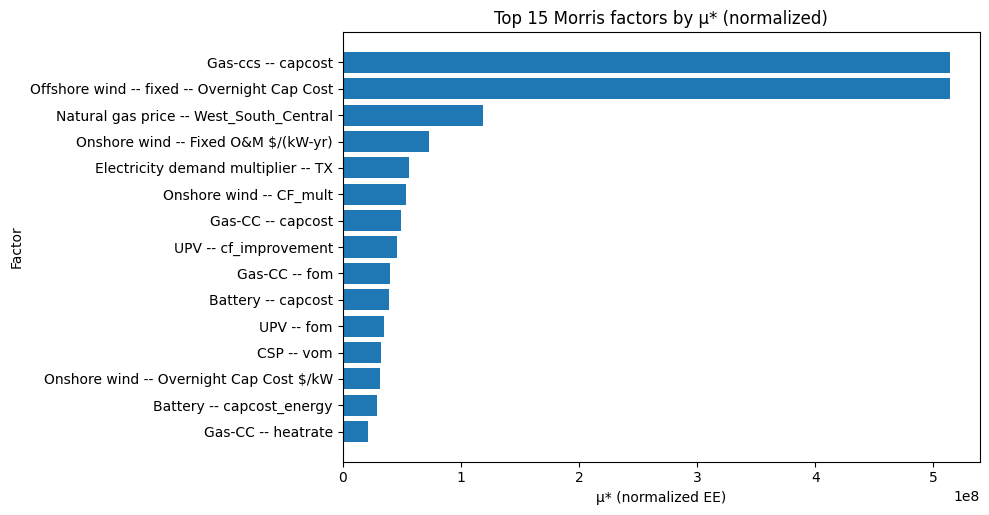

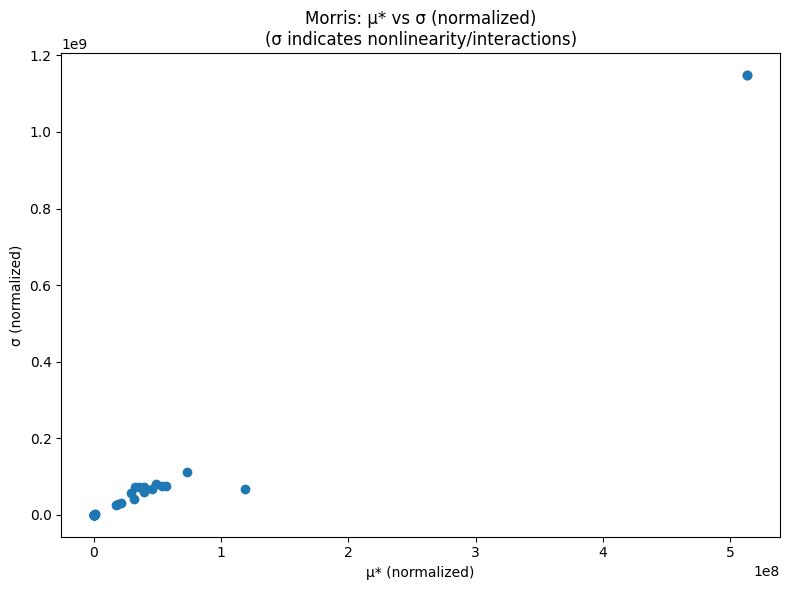

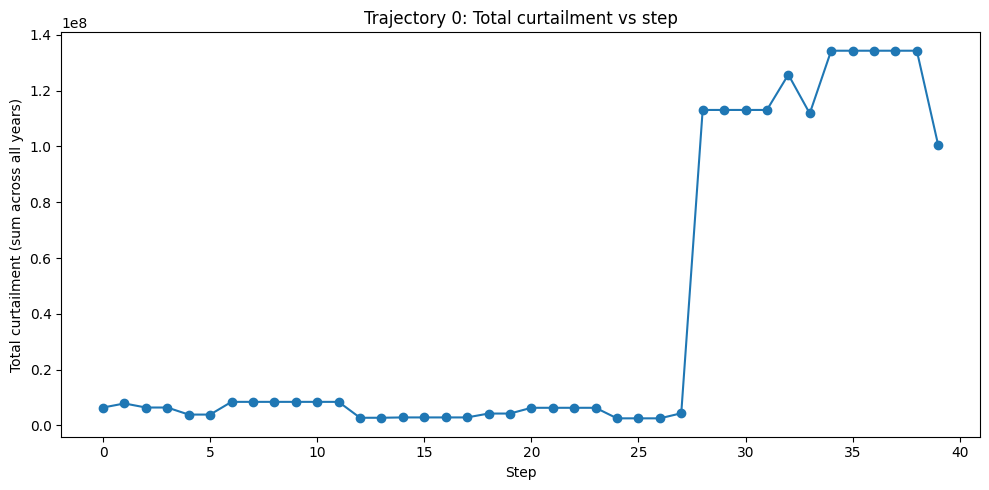

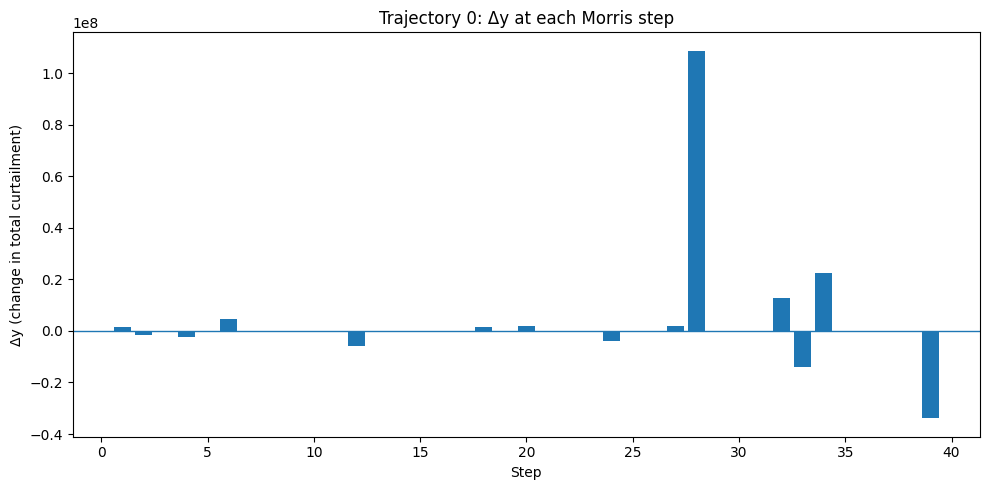

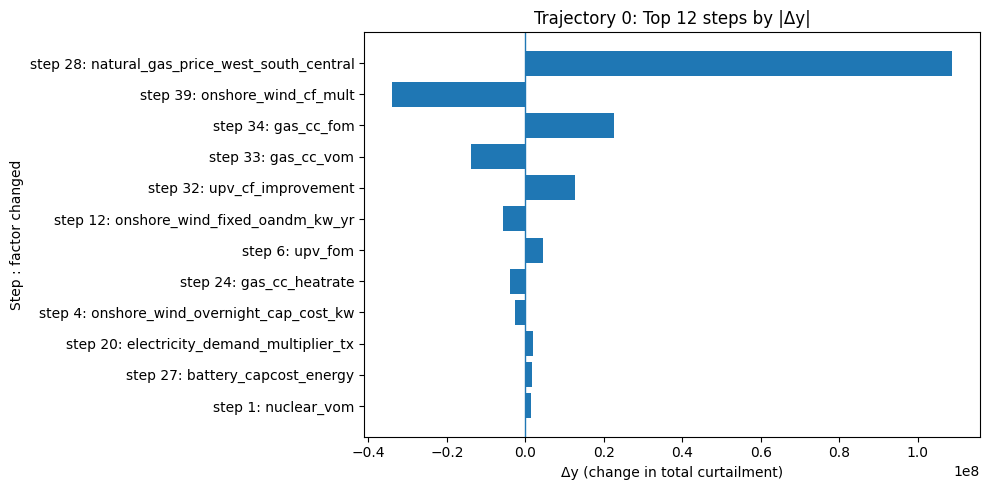

In [5]:
# ============================================================
# GRAPHS for Morris results (matplotlib only, no seaborn)
# Assumes you already ran the earlier blocks and have:
#   - morris_rank_norm_named  (normalized Morris ranking table)
#   - diag_show               (trajectory diagnostics with dx_norm, dy, y)
# If not, re-run the "normalized EE + diagnostics" block first.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Helper: pick label column
# -------------------------------
def _best_label_col(df: pd.DataFrame) -> str:
    for c in ["Parameter", "factor"]:
        if c in df.columns:
            return c
    return df.columns[0]

# -------------------------------
# 1) Bar chart: Top-N by mu_star_norm
# -------------------------------
def plot_top_mu_star_norm(morris_rank_norm_named: pd.DataFrame, top_n: int = 15):
    df = morris_rank_norm_named.copy()
    if "mu_star_norm" not in df.columns:
        raise ValueError("morris_rank_norm_named must contain 'mu_star_norm'.")

    label_col = _best_label_col(df)
    top = df.sort_values("mu_star_norm", ascending=False).head(top_n).copy()

    # Reverse so largest at top in horizontal bar
    top = top.iloc[::-1]

    plt.figure(figsize=(10, max(5, 0.35 * top_n)))
    plt.barh(top[label_col].astype(str), top["mu_star_norm"].astype(float))
    plt.xlabel("μ* (normalized EE)")
    plt.ylabel("Factor")
    plt.title(f"Top {top_n} Morris factors by μ* (normalized)")
    plt.tight_layout()
    plt.show()

# -------------------------------
# 2) Scatter: mu_star_norm vs sigma_norm (if sigma available)
# -------------------------------
def plot_mu_star_vs_sigma(morris_rank_norm_named: pd.DataFrame):
    df = morris_rank_norm_named.copy()
    if not {"mu_star_norm", "sigma_norm"}.issubset(df.columns):
        raise ValueError("Need columns: 'mu_star_norm' and 'sigma_norm'.")

    # sigma is NaN if you only have 1 trajectory; handle gracefully
    valid = df.dropna(subset=["sigma_norm"]).copy()
    if len(valid) == 0:
        print("sigma_norm is NaN for all factors (likely only 1 trajectory).")
        print("Once you have >=2 trajectories, this plot will work automatically.")
        return

    plt.figure(figsize=(8, 6))
    plt.scatter(valid["mu_star_norm"].astype(float), valid["sigma_norm"].astype(float))
    plt.xlabel("μ* (normalized)")
    plt.ylabel("σ (normalized)")
    plt.title("Morris: μ* vs σ (normalized)\n(σ indicates nonlinearity/interactions)")
    plt.tight_layout()
    plt.show()

# -------------------------------
# 3) Trajectory plot: total curtailment y vs step (trajectory 0)
# -------------------------------
def plot_y_over_steps(diag_show: pd.DataFrame, traj: int = 0):
    df = diag_show.copy()
    needed_cols = {"trajectory", "step", "y", "dy", "changed_factor"}
    if not needed_cols.issubset(df.columns):
        raise ValueError(f"diag_show must contain columns: {sorted(needed_cols)}")

    d = df[df["trajectory"] == traj].sort_values("step").copy()
    plt.figure(figsize=(10, 5))
    plt.plot(d["step"].astype(int), d["y"].astype(float), marker="o")
    plt.xlabel("Step")
    plt.ylabel("Total curtailment (sum across all years)")
    plt.title(f"Trajectory {traj}: Total curtailment vs step")
    plt.tight_layout()
    plt.show()

# -------------------------------
# 4) Waterfall-style: dy per step (trajectory 0)
# -------------------------------
def plot_dy_by_step(diag_show: pd.DataFrame, traj: int = 0, steps: int = None):
    df = diag_show.copy()
    d = df[df["trajectory"] == traj].sort_values("step").copy()
    d = d[d["step"] > 0].copy()  # exclude step 0 baseline
    if steps is not None:
        d = d.head(steps)

    plt.figure(figsize=(10, 5))
    plt.bar(d["step"].astype(int), d["dy"].astype(float))
    plt.axhline(0, linewidth=1)
    plt.xlabel("Step")
    plt.ylabel("Δy (change in total curtailment)")
    plt.title(f"Trajectory {traj}: Δy at each Morris step")
    plt.tight_layout()
    plt.show()

# -------------------------------
# 5) Optional: Label the biggest dy steps (trajectory 0)
# -------------------------------
def plot_top_dy_steps(diag_show: pd.DataFrame, traj: int = 0, top_n: int = 12):
    df = diag_show.copy()
    d = df[(df["trajectory"] == traj) & (df["step"] > 0)].copy()
    d["abs_dy"] = d["dy"].abs()
    d = d.sort_values("abs_dy", ascending=False).head(top_n).copy()
    d = d.iloc[::-1]  # for nice horizontal bar ordering

    labels = d.apply(lambda r: f"step {int(r['step'])}: {r['changed_factor']}", axis=1)

    plt.figure(figsize=(10, max(5, 0.4 * top_n)))
    plt.barh(labels, d["dy"].astype(float))
    plt.axvline(0, linewidth=1)
    plt.xlabel("Δy (change in total curtailment)")
    plt.ylabel("Step : factor changed")
    plt.title(f"Trajectory {traj}: Top {top_n} steps by |Δy|")
    plt.tight_layout()
    plt.show()

# ============================================================
# RUN THE PLOTS
# ============================================================
plot_top_mu_star_norm(morris_rank_norm_named, top_n=15)
plot_mu_star_vs_sigma(morris_rank_norm_named)

plot_y_over_steps(diag_show, traj=0)
plot_dy_by_step(diag_show, traj=0)          # all steps
plot_top_dy_steps(diag_show, traj=0, top_n=12)
